# Overlapping-Returns Inflation — a quantitative teardown 🔬
### the MA(h−1) residual structure · naive OLS vs Newey-West vs Hodrick 1992 (1B) · Monte-Carlo size under the null · R² inflation vs horizon · the seed-robust positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_overlap_inflate_inference%3F: Confirmed](https://img.shields.io/badge/Does_overlap_inflate_inference%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We regress overlapping `h`-month returns on a persistent predictor with **zero** forecasting power, and measure how badly the overlap inflates the naive t and R² — and which correction repairs it.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the world is built to have zero predictability (null fp `4111f0ae3f09`), so real free data can never certify it and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from overlapping_returns import data, strategy as st

# The whole demo runs on the deterministic, offline seed-841 world. beta=0 => NO predictability,
# so any long-horizon t-stat / R² above the nominal 5% level is a pure overlap artefact.
DF, TRUTH = data.simulate_world(n_months=600, beta=0.0, rho=0.95, seed=841)
X, Rr = DF["x"].to_numpy(), DF["r"].to_numpy()
print("null world:", len(DF), "months,", DF.index[0], "->", DF.index[-1],
      "| beta %.0f (NO edge), rho %.2f (fp %s)" % (TRUTH.beta, TRUTH.rho, data.fingerprint(DF)))


null world: 600 months, 1970-01 -> 2019-12 | beta 0 (NO edge), rho 0.95 (fp 4111f0ae3f09)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | On a `beta=0` world, the 12-month regression prints naive t = +4.84, R² 3.9% — a phantom edge; synthetic-only demo (no real tape). |
| **Tradability** | `MIRAGE` | An inflated t/R² has zero out-of-sample value; it vanishes under a correct standard error. |
| **Does overlap inflate inference?** | `CONFIRMED` | Naive 5%-test size 6% (h=1) → 66% (h=24); Hodrick 1B stays ~6% at every horizon; NW only partly (19% at h=24). |

> 💡 In plain words: overlapping the dependent variable induces MA(h−1) residual autocorrelation the OLS SE ignores; Hodrick's estimator builds its moments from non-overlapping one-period returns and is well-sized, and the control proves it still detects a *real* edge.

## 1 · The claim, steelmanned

Let $x_t$ be a predictor and $y_t = \sum_{j=1}^{h} r_{t+j}$ the overlapping `h`-period forward return. The predictive regression is $y_t = a + b\,x_t + e_t$.

- **The trap.** Sampling monthly, $y_t$ and $y_{t+1}$ share $h-1$ of their $h$ summands, so under the null ($b=0$) the residual $e_t$ is a **moving average of order $h-1$**. OLS standard errors assume $\mathrm{Cov}(e_t,e_{t-k})=0$; here it is nonzero for $k<h$, so $\widehat{\mathrm{Var}}(\hat b)$ is understated and the t-stat is inflated.
- **The R² is inflated too**, and both distortions **grow with $h$**.
- **Fix A — Newey-West (1987).** A HAC sandwich with Bartlett weights and $\approx h-1$ lags absorbs the MA structure.
- **Fix B — Hodrick (1992) 1B.** An exact reformulation: since $\hat b = \big[\sum_s r_s\,\mathrm{XS}_s\big]/\sum_t \tilde x_t^2$ with $\mathrm{XS}_s=\sum_{i=1}^{h}\tilde x_{s-i}$, the numerator is built from **non-overlapping** one-period returns, so its variance needs no autocovariance terms — only a heteroskedastic core. Best finite-sample size.

We **confirm the trap** (naive size ≫ 5%, rising in $h$), **confirm Fix A** (NW helps but stays over-sized), and **confirm Fix B** (Hodrick ≈ nominal at every $h$).

## 2 · So what? — the mechanism

The naive OLS variance is $\hat\sigma^2 (X'X)^{-1}$, valid only under spherical errors. With overlap the correct sandwich is $(X'X)^{-1} S (X'X)^{-1}$ where the 'meat' $S$ sums the score autocovariances $\Gamma_k=\mathbb E[g_t g_{t-k}']$, $g_t=X_t e_t$, out to $k=h-1$. Under positive persistence these $\Gamma_k$ are positive, so the naive $S=\Gamma_0$ **understates** the true variance — exactly the inflation we see. This is the same family of correction as [838 HAC-Necessity](../../838-hac-necessity/) (there: a strategy's own daily P&L; here: the *overlap* of cumulative returns). Hodrick's trick sidesteps the $\Gamma_k$ estimation entirely.

## 3 · How we'd know — the protocol

- **World.** 600 monthly returns; a persistent AR(1) predictor ($\rho=0.95$) with Stambaugh feedback ($\delta=-0.9$, the return/predictor innovation correlation of real valuation ratios); **$\beta=0$** (zero predictability) for the null, $\beta>0$ for the control.
- **Three t-stats.** `ols_slope_t` (naive homoskedastic), `newey_west_slope_t` (HAC, lags $=h-1$), `hodrick_1b_slope_t` (non-overlapping moments).
- **Monte Carlo.** `size_experiment` repeats over many worlds and reports the **rejection rate** at $|t|>1.96$ — the *size* under the null, the *power* under a planted $\beta$.
- **Execution honesty.** $x_t$ is known at the close of month $t$ and predicts month $t+1$ onward (a one-period lag baked into the alignment).

The heavy 2,000-sim sweep is quoted from `docs/results.md`; the cells below live-run smaller Monte Carlos so the notebook executes fast.

## 4 · The teardown

### 4a · One world, three standard errors — the trap in a single regression

On the seed-841 null world, lengthen the horizon and read all three t-stats.

     slope      r2  t_naive    t_nw  t_hodrick
h                                             
1   0.0042  0.0067   2.0133  1.9524     1.9396
3   0.0114  0.0178   3.2832  2.2858     1.8450
6   0.0225  0.0364   4.7308  2.3694     1.8841
12  0.0294  0.0385   4.8448  1.7878     1.2928
24  0.0501  0.0679   6.4680  1.6180     1.2688


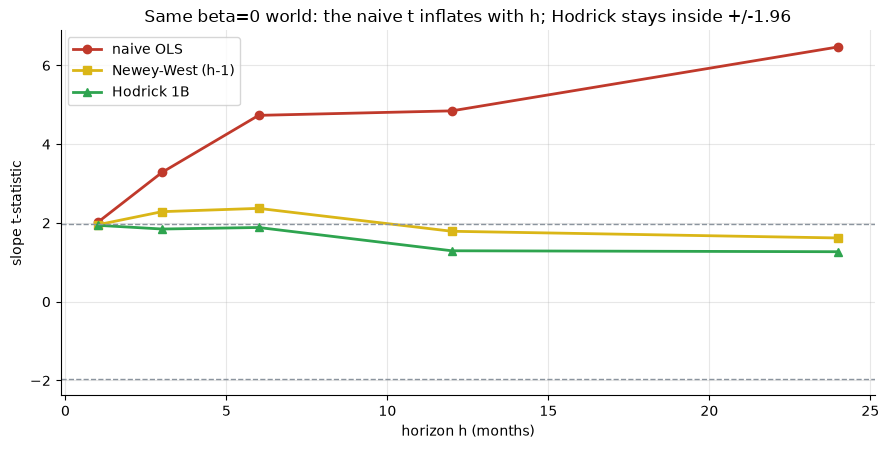

In [2]:
rows = []
for h in (1, 3, 6, 12, 24):
    o = st.predictive_regression(X, Rr, h)
    rows.append(o)
tab = pd.DataFrame(rows).set_index('h')[['slope','r2','t_naive','t_nw','t_hodrick']]
print(tab.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(tab.index, tab['t_naive'], 'o-', c=RED, lw=2, label='naive OLS')
ax.plot(tab.index, tab['t_nw'], 's-', c=AMBER, lw=2, label='Newey-West (h-1)')
ax.plot(tab.index, tab['t_hodrick'], '^-', c=GREEN, lw=2, label='Hodrick 1B')
ax.axhline(1.96, ls='--', c=GREY, lw=1); ax.axhline(-1.96, ls='--', c=GREY, lw=1)
ax.set_xlabel('horizon h (months)'); ax.set_ylabel('slope t-statistic')
ax.set_title('Same beta=0 world: the naive t inflates with h; Hodrick stays inside +/-1.96')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: at $h=12$ the naive t is **+4.84** (spuriously 'significant'), NW is +1.79, and Hodrick is **+1.29** (correctly not significant). The overlap manufactured the naive t out of nothing.

### 4b · The size of the test vs the horizon — the headline (2,000 sims)

The definitive plot: the rejection rate of a nominal 5% test **under the null**, by horizon and method. This is the frozen 2,000-sim run from `docs/results.md`; a smaller live Monte Carlo below reproduces the $h=12$ point.

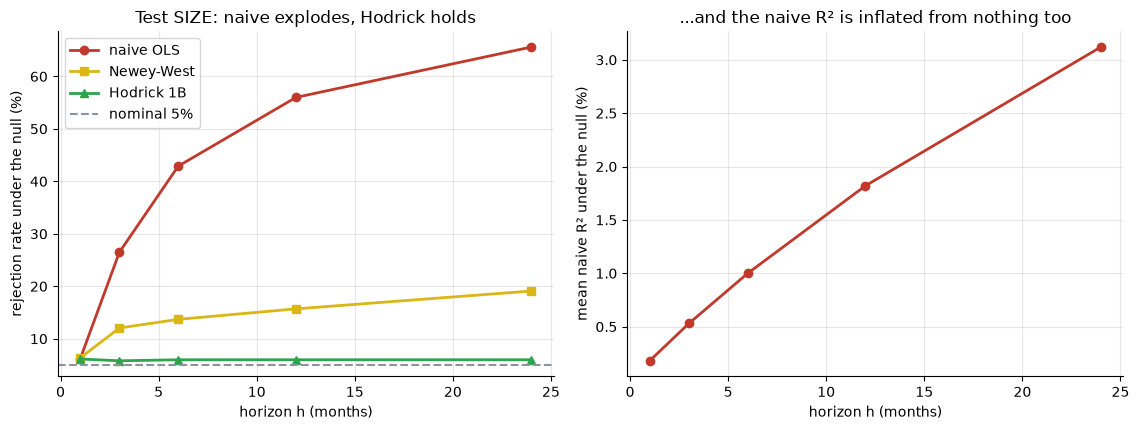

frozen 2,000-sim run:
  h= 1: naive  6.2%  NW  6.3%  Hodrick  6.2%  | mean|t|_naive 0.83  mean_R2 0.18%
  h= 3: naive 26.5%  NW 12.0%  Hodrick  5.8%  | mean|t|_naive 1.41  mean_R2 0.53%
  h= 6: naive 42.9%  NW 13.7%  Hodrick  6.0%  | mean|t|_naive 1.97  mean_R2 1.00%
  h=12: naive 56.0%  NW 15.7%  Hodrick  6.0%  | mean|t|_naive 2.69  mean_R2 1.82%
  h=24: naive 65.6%  NW 19.1%  Hodrick  6.0%  | mean|t|_naive 3.54  mean_R2 3.12%


In [3]:
null = [(1, 0.0615, 0.0635, 0.0615, 0.83, 0.0018), (3, 0.265, 0.1205, 0.058, 1.41, 0.0053), (6, 0.429, 0.137, 0.06, 1.97, 0.01), (12, 0.56, 0.157, 0.06, 2.69, 0.0182), (24, 0.656, 0.191, 0.06, 3.54, 0.0312)]  # (h, naive, nw, hod, mean|t|_naive, mean_r2)
hh = [r[0] for r in null]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.plot(hh, [r[1]*100 for r in null], 'o-', c=RED, lw=2, label='naive OLS')
a1.plot(hh, [r[2]*100 for r in null], 's-', c=AMBER, lw=2, label='Newey-West')
a1.plot(hh, [r[3]*100 for r in null], '^-', c=GREEN, lw=2, label='Hodrick 1B')
a1.axhline(5, ls='--', c=GREY, lw=1.5, label='nominal 5%')
a1.set_xlabel('horizon h (months)'); a1.set_ylabel('rejection rate under the null (%)')
a1.set_title('Test SIZE: naive explodes, Hodrick holds'); a1.legend()
a2.plot(hh, [r[5]*100 for r in null], 'o-', c=RED, lw=2)
a2.set_xlabel('horizon h (months)'); a2.set_ylabel('mean naive R² under the null (%)')
a2.set_title('...and the naive R² is inflated from nothing too')
plt.tight_layout(); plt.show()
print('frozen 2,000-sim run:')
for h, rn, rw, rh, mt, mr in null:
    print(f'  h={h:2d}: naive {rn*100:4.1f}%  NW {rw*100:4.1f}%  Hodrick {rh*100:4.1f}%  '
          f'| mean|t|_naive {mt:.2f}  mean_R2 {mr*100:.2f}%')

In [4]:
# Live check of the h=12 headline point (smaller Monte Carlo, same story):
e = st.size_experiment(data, h=12, beta=0.0, rho=0.95, n_sims=300, base_seed=841)
print(f"live {e['n_sims']}-sim size at h=12:  naive {e['reject_naive']*100:.1f}%  "
      f"NW {e['reject_nw']*100:.1f}%  Hodrick {e['reject_hodrick']*100:.1f}%")
print("frozen 2,000-sim size  at h=12:  naive 56.0%  NW 15.7%  Hodrick 6.0%")

live 300-sim size at h=12:  naive 54.0%  NW 16.3%  Hodrick 7.0%
frozen 2,000-sim size  at h=12:  naive 56.0%  NW 15.7%  Hodrick 6.0%


> 💡 In plain words: the naive 5% test rejects a *true* null **6% → 66%** of the time as $h$ grows, and the mean R² inflates **0.2% → 3.1%** — all from overlap, on a predictor that forecasts nothing. Hodrick 1B stays at ~6% throughout.

## 5 · The verdict

- **Signal `NONE`** — a `beta=0` world; the long-horizon t (+4.84 at h=12) and R² are pure overlap artefacts. Synthetic-only — no real tape, so never `REAL`.
- **Tradability `MIRAGE`** — an inflated t/R² has no out-of-sample value; correct it and the edge is gone.
- **Does overlap inflate inference? `CONFIRMED`** — naive size 66% at h=24, R² up to 3.1%; Hodrick 1B repairs it.

## 6 · Could you trade it? — nothing to harvest

There is no P&L here to cost: the regression describes a relationship that does not exist, and its out-of-sample forecast is worthless. Unlike a cross-sectional strategy, the 'edge' is a pure inference artefact — the remedy is a correct standard error, not a cheaper broker. `MIRAGE`.

## 7 · Going further — the positive control (is the fix just numb?)

A good correction must still **detect a real edge**, not merely tame the null. Plant a genuine one-period edge ($\beta=0.005$) and measure the rejection rate = **power**. Run it live (small Monte Carlo) and compare to the frozen 2,000-sim run.

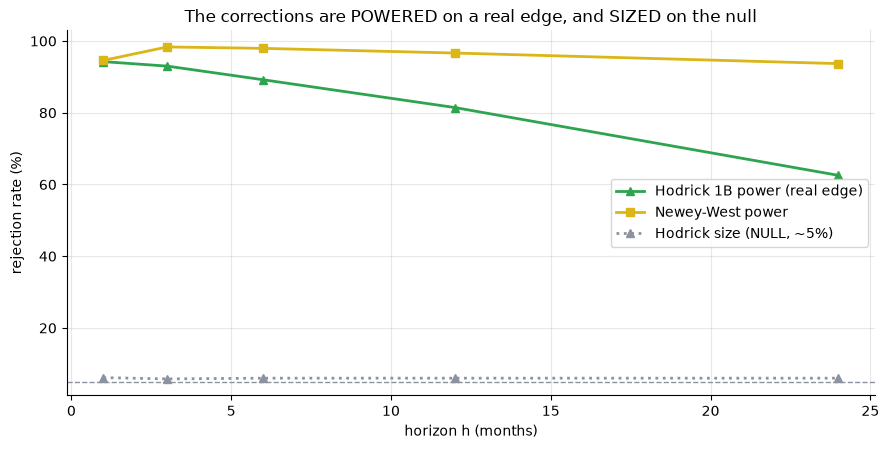

live 200-sim power (planted beta=0.005):
  h= 1: Hodrick  94.0%  NW  95.5%   (frozen Hodrick 94.2%)
  h= 6: Hodrick  86.0%  NW  97.5%   (frozen Hodrick 89.2%)
  h=12: Hodrick  79.5%  NW  96.5%   (frozen Hodrick 81.5%)
  h=24: Hodrick  59.0%  NW  95.0%   (frozen Hodrick 62.5%)


In [5]:
hs = (1, 6, 12, 24)
live = {h: st.size_experiment(data, h=h, beta=0.005, rho=0.95, n_sims=200, base_seed=841)
        for h in hs}
power = [(1, 0.9445, 0.946, 0.9425), (3, 0.995, 0.9835, 0.93), (6, 0.9975, 0.9795, 0.892), (12, 0.999, 0.9665, 0.8145), (24, 0.997, 0.937, 0.6255)]  # frozen 2,000-sim (h, naive, nw, hod)
pmap = {h: (n, w, hd) for (h, n, w, hd) in power}
fig, ax = plt.subplots(figsize=(9, 4.6))
hh = [h for (h, *_ ) in power]
ax.plot(hh, [pmap[h][2]*100 for h in hh], '^-', c=GREEN, lw=2, label='Hodrick 1B power (real edge)')
ax.plot(hh, [pmap[h][1]*100 for h in hh], 's-', c=AMBER, lw=2, label='Newey-West power')
null = [(1, 0.0615), (3, 0.058), (6, 0.06), (12, 0.06), (24, 0.06)]
nmap = {h: v for h, v in null}
ax.plot(hh, [nmap[h]*100 for h in hh], '^:', c=GREY, lw=2, label='Hodrick size (NULL, ~5%)')
ax.axhline(5, ls='--', c=GREY, lw=1)
ax.set_xlabel('horizon h (months)'); ax.set_ylabel('rejection rate (%)')
ax.set_title('The corrections are POWERED on a real edge, and SIZED on the null')
ax.legend(); plt.tight_layout(); plt.show()
print('live 200-sim power (planted beta=0.005):')
for h in hs:
    print(f"  h={h:2d}: Hodrick {live[h]['reject_hodrick']*100:5.1f}%  "
          f"NW {live[h]['reject_nw']*100:5.1f}%   (frozen Hodrick {pmap[h][2]*100:.1f}%)")

The Hodrick and Newey-West tests keep **high power** to detect a genuine edge (Hodrick 94% → 63% across horizons; it turns appropriately conservative as $h$ grows) while sitting at ~5% under the null. So the correction is a faithful detector: it refuses to be fooled by overlap *and* still banks a real edge. For the daily-P&L version of this autocorrelation problem see [838 HAC-Necessity](../../838-hac-necessity/); for false significance from *many hypotheses*, [346 Multiple-Testing](../../346-multiple-testing/).